In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
df = pd.read_csv('zuu crew scores.csv')
df.head(5)

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
3,Nisal Gamage,1,74.5,63.9,7,0,76.8,1.7,Production-Ready ML Systems,100.0
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1


In [85]:
df = df[df['CourseName'] == 'Foundations of ML']
df.head()

,MemberName,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CourseName,CapstoneScore
0,Theekshana Rathnayake,3,79.9,43.7,2,0,62.8,5.0,Foundations of ML,45.3
1,Mayura Sandakalum Sellapperuma,2,76.8,95.6,6,0,87.4,2.7,Foundations of ML,78.8
2,Amila Narangoda,3,96.6,75.9,8,0,98.4,2.8,Foundations of ML,65.4
4,Tharusha Vihanga,2,83.2,24.0,6,0,41.8,4.2,Foundations of ML,40.1
7,Chamath Perera,3,86.5,88.0,5,0,23.9,1.3,Foundations of ML,68.2


In [86]:
X = df[ 'TotalHours' ].values.reshape(-1, 1)
Y = df[ 'CapstoneScore' ].values

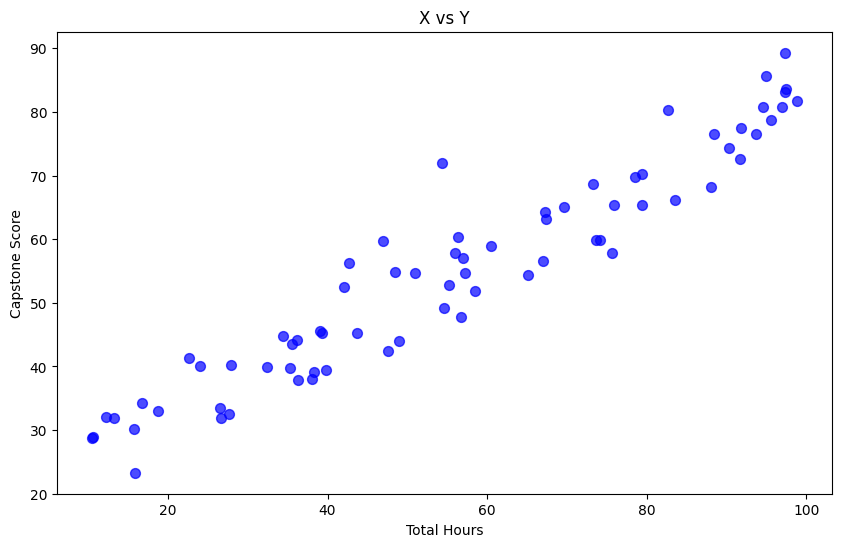

In [87]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.7, color='blue', s=50)
plt.xlabel('Total Hours')
plt.ylabel('Capstone Score')
plt.title('X vs Y')
plt.show()

In [88]:
def compute_cost(X, Y, beta):
    """ 
        X : (m, n)
        Y : (m, )
        beta : (beta0, beta1)

        MSE = >  sum(( y_hat - y ) ** 2)
        X.dot(beta) => beta0 + beta1.x1 + ...... + betaj.xj + ...... + betan.xn   
    """

    m= len(Y)
    y_hat = X.dot(beta)
    cost = ( 1 / (2 * m) ) * np.sum((y_hat - Y) ** 2)
    return cost

def gradient_descent(X, Y, beta, lr, n_iter):
    """ 
    X : (m, n) -> after adding bias : (m, n+1) -> (72, 2) | If I take transpose -> (2, 72)

    dj/dbetaj = (1 / m) * X.T * (y_hat - y)
    """

    m = len(Y)
    cost_history = []

    for i in range(n_iter):

        y_hat = X.dot(beta)
        gradients = (1 / m) * X.T.dot(y_hat - Y)

        beta = beta - lr * gradients
        cost = compute_cost(X, Y, beta)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration: {i}: cost: {cost:.4f} ")

    return cost_history,beta     

In [89]:
""" 
    y_hat = beta0.x0 + beta1.x1; xo = 1
    X = [1, x1]

"""


X_with_bias = np.column_stack([np.ones((len(X))), X])
X_with_bias

array([[ 1. , 43.7],
       [ 1. , 95.6],
       [ 1. , 75.9],
       [ 1. , 24. ],
       [ 1. , 88. ],
       [ 1. , 97.3],
       [ 1. , 26.5],
       [ 1. , 57.2],
       [ 1. , 48.9],
       [ 1. , 36.2],
       [ 1. , 65.1],
       [ 1. , 22.6],
       [ 1. , 36.3],
       [ 1. , 51. ],
       [ 1. , 56.3],
       [ 1. , 15.9],
       [ 1. , 96.9],
       [ 1. , 18.8],
       [ 1. , 54.6],
       [ 1. , 91.8],
       [ 1. , 69.6],
       [ 1. , 38.1],
       [ 1. , 26.6],
       [ 1. , 97.3],
       [ 1. , 94.6],
       [ 1. , 27.6],
       [ 1. , 39.3],
       [ 1. , 34.4],
       [ 1. , 42.1],
       [ 1. , 35.3],
       [ 1. , 98.8],
       [ 1. , 27.9],
       [ 1. , 10.5],
       [ 1. , 73.6],
       [ 1. , 75.6],
       [ 1. , 79.4],
       [ 1. , 16.7],
       [ 1. , 39.8],
       [ 1. , 15.7],
       [ 1. , 67.4],
       [ 1. , 74.2],
       [ 1. , 78.5],
       [ 1. , 60.5],
       [ 1. , 79.4],
       [ 1. , 54.4],
       [ 1. , 57. ],
       [ 1. , 48.5],
       [ 1. ,

In [90]:
beta = np.random.randn(2)
print(f"beta values : {beta}")

lr = 0.000001
n_iter = 10000

beta values : [0.98558477 1.82576932]


In [91]:
cost_history, beta = gradient_descent(X_with_bias, Y, beta, lr, n_iter)

Iteration: 0: cost: 1684.3688 
Iteration: 100: cost: 804.6868 
Iteration: 200: cost: 397.9688 
Iteration: 300: cost: 209.9238 
Iteration: 400: cost: 122.9813 
Iteration: 500: cost: 82.7831 
Iteration: 600: cost: 64.1970 
Iteration: 700: cost: 55.6030 
Iteration: 800: cost: 51.6290 
Iteration: 900: cost: 49.7909 
Iteration: 1000: cost: 48.9403 
Iteration: 1100: cost: 48.5464 
Iteration: 1200: cost: 48.3636 
Iteration: 1300: cost: 48.2783 
Iteration: 1400: cost: 48.2382 
Iteration: 1500: cost: 48.2190 
Iteration: 1600: cost: 48.2094 
Iteration: 1700: cost: 48.2043 
Iteration: 1800: cost: 48.2012 
Iteration: 1900: cost: 48.1991 
Iteration: 2000: cost: 48.1974 
Iteration: 2100: cost: 48.1959 
Iteration: 2200: cost: 48.1946 
Iteration: 2300: cost: 48.1932 
Iteration: 2400: cost: 48.1919 
Iteration: 2500: cost: 48.1906 
Iteration: 2600: cost: 48.1893 
Iteration: 2700: cost: 48.1880 
Iteration: 2800: cost: 48.1867 
Iteration: 2900: cost: 48.1854 
Iteration: 3000: cost: 48.1841 
Iteration: 310

In [92]:
print(f"beat beta : {beta}")

beat beta : [1.00809619 0.89982845]


In [93]:
x_min, x_max = float(np.min(X)), float(np.max(X))
x_interval = np.linspace(x_min, x_max, 100)
x_interval_with_bias = np.column_stack([np.ones((len(x_interval))), x_interval])
y_hat_interval = x_interval_with_bias.dot(beta)
y_hat_interval

array([10.45629488, 11.25886915, 12.06144341, 12.86401767, 13.66659193,
       14.46916619, 15.27174045, 16.07431471, 16.87688898, 17.67946324,
       18.4820375 , 19.28461176, 20.08718602, 20.88976028, 21.69233454,
       22.49490881, 23.29748307, 24.10005733, 24.90263159, 25.70520585,
       26.50778011, 27.31035437, 28.11292863, 28.9155029 , 29.71807716,
       30.52065142, 31.32322568, 32.12579994, 32.9283742 , 33.73094846,
       34.53352273, 35.33609699, 36.13867125, 36.94124551, 37.74381977,
       38.54639403, 39.34896829, 40.15154255, 40.95411682, 41.75669108,
       42.55926534, 43.3618396 , 44.16441386, 44.96698812, 45.76956238,
       46.57213665, 47.37471091, 48.17728517, 48.97985943, 49.78243369,
       50.58500795, 51.38758221, 52.19015647, 52.99273074, 53.795305  ,
       54.59787926, 55.40045352, 56.20302778, 57.00560204, 57.8081763 ,
       58.61075057, 59.41332483, 60.21589909, 61.01847335, 61.82104761,
       62.62362187, 63.42619613, 64.22877039, 65.03134466, 65.83

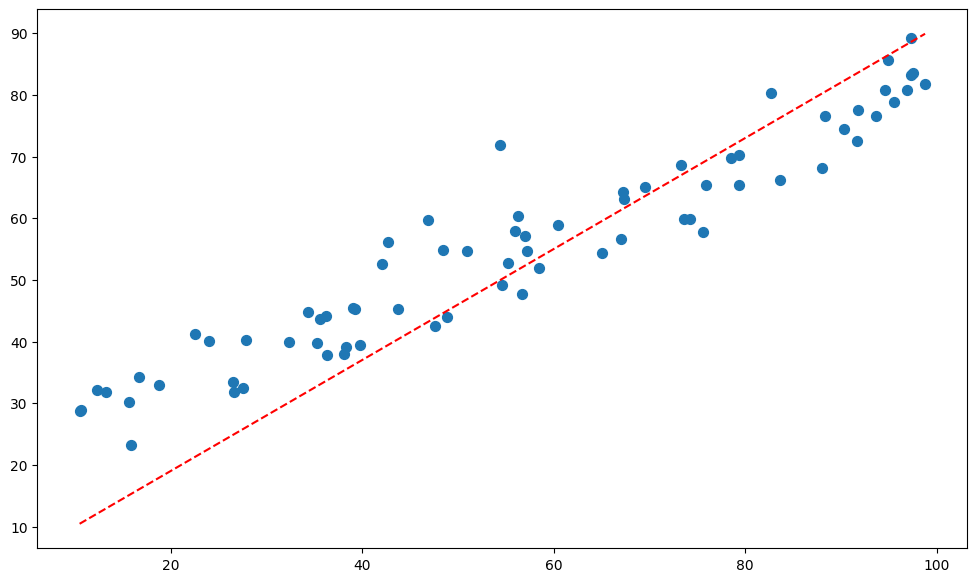

In [94]:
plt.figure(figsize=(12, 7))

plt.scatter(X, Y, s=50, label="actual data")

plt.plot(x_interval, y_hat_interval, 'r--', label="fitted line")

plt.show()

##### how to evaluate ?

    - MSE : Mean squared error
    - RMSE : Root mean squared error
    - MAE : Mean absolute error
    - R^2 : R-squared